In [1]:
from typing import List, TypedDict
from langgraph.graph import StateGraph

In [3]:
class AgentState(TypedDict):
  values: List[str]
  name: str
  operations: str
  result: str

In [10]:
from math import prod

def process_values(state: AgentState) -> AgentState:
  state["result"] = f"hey {state['name']}, your value is {prod(state['values']) if state['operations'] == '*' else sum(state['values'])}"

  return state

In [11]:
graph= StateGraph(AgentState)

graph.add_node("process_values", process_values)
graph.set_entry_point("process_values")
graph.set_finish_point("process_values")

app= graph.compile()  

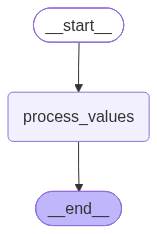

In [12]:
from IPython.display import display, Image
display(Image(app.get_graph().draw_mermaid_png()))

In [16]:
answer= app.invoke({"values": [1,2,3,4], "name": "Krityan", "operations": "+"})

In [17]:
print(answer["result"])

hey Krityan, your value is 10
